# Check temporal alignment between drone missions

This notebook tries to measure temporal alignment between drone flights covering a common area. 

Parting from the fact that the mean canopy height remains somewhat stable through the year. A mean difference of 2-1m is expected due to changes in the canopy, such as trees dying and falling. A bigger difference of > 5m probably indicates that the two orthomosaics are not very well aligned.

In the absence of ground control points in the forest, this is a way to measure the alignment. But could still be improved by testing if the measures correlate to the quality of the alignment of the orthomosaics.


## Load missions to be compared

In [ ]:
import pandas as pd
import numpy as np

import rasterio
import matplotlib.pyplot as plt
import os
import geopandas as gpd
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling

In [ ]:
# read all the PROCESSED missions in 2024 and 2025
missions_path = r"Products\Drone"

missions_2024 = os.listdir(os.path.join(missions_path, '2024'))
missions_2025 = os.listdir(os.path.join(missions_path, '2025'))

missions_processed = missions_2024 + missions_2025

In [ ]:
# extract the date
# convert into a dataframe and extract the date
missions_list = pd.DataFrame()

missions_list['mission'] =  missions_processed
missions_list['base'] = (
    missions_list['mission']
    .str.rsplit('_', n=1)
    .str[0]
)
missions_list['date'] = missions_list['mission'].str.extract(r'BCI_50ha_(\d{4}_\d{2}_\d{2})')[0]
missions_list['date'] = pd.to_datetime(missions_list['date'], format='%Y_%m_%d')
# add information about the processing if there is any

missions_processing_path = r"Raw\Drone\missions_processing.xlsx"
missions_processing_info = pd.read_excel(missions_processing_path)

missions_processing_info['base'] = (
    missions_processing_info['mission']
    .str.rsplit('_', n=1)
    .str[0]
)

# do like a left join by the column mission and add the columns antenna and comments_processing
missions_list = missions_list.merge(
    missions_processing_info[
        ['mission', 'antenna', 'comments_processing']
    ],
    on='mission',
    how='left'
)

missions_list['antenna'] = np.where(
    missions_list['comments_processing'].isna() &
    (~missions_list['antenna'].isna()),

    missions_list['antenna'],
    'Unknown'
)

In [139]:
missions_list[missions_list['antenna'] == 'Unknown']

,mission,base,date,antenna,comments_processing
1,BCI_50ha_2024_01_03_P4P,BCI_50ha_2024_01_03,2024-01-03,Unknown,NaN
2,BCI_50ha_2024_01_09_P4P,BCI_50ha_2024_01_09,2024-01-09,Unknown,NaN
3,BCI_50ha_2024_01_17_P4P,BCI_50ha_2024_01_17,2024-01-17,Unknown,NaN
4,BCI_50ha_2024_01_25_P4P,BCI_50ha_2024_01_25,2024-01-25,Unknown,NaN
5,BCI_50ha_2024_02_01_P4P,BCI_50ha_2024_02_01,2024-02-01,Unknown,NaN
...,...,...,...,...,...
141,BCI_50ha_2025_11_18_M3M,BCI_50ha_2025_11_18,2025-11-18,Unknown,NaN
148,BCI_50ha_2025_12_29_M3E_old,BCI_50ha_2025_12_29_M3E,2025-12-29,Unknown,NaN
150,SANLORENZO_sherman_2025_01_07_M3M,SANLORENZO_sherman_2025_01_07,NaT,Unknown,NaN
151,SANTARITA_fincaroubik_2025_01_30_M3E,SANTARITA_fincaroubik_2025_01_30,NaT,Unknown,NaN


In [140]:
# keep only missions that are mavic
missions_list = missions_list[
    missions_list["mission"].str.contains("M3M|M3E", na=False)
]

In [141]:
# keep only missions that are BCI 50ha
missions_list = missions_list[
    missions_list["mission"].str.contains("BCI_50ha", na=False)
]

In [143]:
# keep only missions that are BCI 50ha
missions_list = missions_list[
    ~missions_list["mission"].str.contains("_old", na=False)
]

In [ ]:
# look for flights that have not been processed
# read all the RAW missions in 2024 and 2025
missions_path = r"Raw\Drone"

missions_2024 = os.listdir(os.path.join(missions_path, '2024'))
missions_2025 = os.listdir(os.path.join(missions_path, '2025'))

missions_raw = missions_2024 + missions_2025

In [147]:
missions_raw_df = pd.DataFrame()

missions_raw_df['mission'] =  missions_raw
missions_raw_df['base'] = (
    missions_raw_df['mission']
    .str.rsplit('_', n=1)
    .str[0]
)
missions_raw_df['date'] = missions_raw_df['mission'].str.extract(r'BCI_50ha_(\d{4}_\d{2}_\d{2})')[0]
missions_raw_df['date'] = pd.to_datetime(missions_raw_df['date'], format='%Y_%m_%d')

In [148]:
missing_missions = missions_raw_df[
    ~missions_raw_df['base'].isin(missions_list['base']) &
    ~missions_raw_df['base'].str.contains('WPT')
]

display(
    missing_missions.sort_values('base')
)

,mission,base,date
0,BCI_10ha_ALT60_2024_11_25_M3E,BCI_10ha_ALT60_2024_11_25,NaT
1,BCI_25ha_2024_06_18_M3E,BCI_25ha_2024_06_18,NaT
123,BCI_25ha_2025_02_03_M3E,BCI_25ha_2025_02_03,NaT
124,BCI_25ha_2025_17_06_M3E,BCI_25ha_2025_17_06,NaT
2,BCI_25ha_ALT60_2024_11_25_M3E,BCI_25ha_ALT60_2024_11_25,NaT
...,...,...,...
118,SOBERANIA_p23_2024_08_06_M3E,SOBERANIA_p23_2024_08_06,NaT
119,SOBERANIA_p24_2024_08_06_M3E,SOBERANIA_p24_2024_08_06,NaT
112,crownmap_data_all,crownmap_data,NaT
216,crownmaps_2025_lefo_lab,crownmaps_2025_lefo,NaT


## Measure difference in DSM

In [ ]:
# Load common shapefile

shape50ha_path = r"D:\uzcateguipaula\BCI_50ha_Plot_shape.gpkg"
shape50ha = gpd.read_file(shape50ha_path)


In [ ]:
# Path to the processed products root   
products_root = r"Products\Drone"

missions_list['std_diff'] = np.nan
missions_list['mean_diff'] = np.nan

missions_list['std_diff_crownmap'] = np.nan
missions_list['mean_diff_crownmap'] = np.nan

def find_dsm(mission):
    mission_name = mission['mission']
    mission_folder = os.path.join(products_root, str(mission['date'].year), mission_name)
    try:
        os.listdir(mission_folder)

    except FileNotFoundError:
        print(f"Mission folder not found: {mission_folder}")
        return None
    
    dsm_path = os.path.join(products_root, str(mission['date'].year), mission_name, "DSM")

    # find the most recent dsm file in the folder
    dsm_files = [f for f in os.listdir(dsm_path) if f.endswith('.tif')]
    dsm_files.sort(key=lambda x: os.path.getmtime(os.path.join(dsm_path, x)), reverse=True)
    
    if not dsm_files:
        print(f"No DSM files found in: {dsm_path}")
        return None
    
    return os.path.join(dsm_path, dsm_files[0])

def to_reference_grid(dsm, src_transform, src_crs):
    out = np.empty(ref_shape, dtype=np.float32)

    reproject(
        source=dsm,
        destination=out,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        resampling=Resampling.nearest
    )

    return out

In [ ]:
# Set reference mission, this will be the grid we will use to reproject our missions. 
# They dont match 1:1 because they have different GSD
ref_mission = missions_list[missions_list['mission'] == 'BCI_50ha_2024_11_12_M3E'].iloc[0]
ref_path = find_dsm(ref_mission)

with rasterio.open(ref_path) as ref:

    ref_array = ref.read(1).astype(np.float32)

    if ref.nodata is not None:
        ref_array[ref_array == ref.nodata] = np.nan

    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_shape = ref_array.shape



In [ ]:
# Set up for reference mission

previous_mission = missions_list.iloc[0]
dsm_path = find_dsm(previous_mission)

# open the dsm
with rasterio.open(dsm_path) as src:
    dsm = src.read(1).astype(np.float32)

    if src.nodata is not None:
        dsm[dsm == src.nodata] = np.nan

    # ALIGN TO FIXED GRID 
    dsm_aligned = to_reference_grid(dsm, src.transform, src.crs)
    
    # apply mask
    with rasterio.io.MemoryFile() as memfile:
        with memfile.open(
            driver='GTiff',
            height=ref_shape[0],
            width=ref_shape[1],
            count=1,
            dtype=dsm_aligned.dtype,
            transform=ref_transform,
            crs=ref_crs
        ) as tmp:
            tmp.write(dsm_aligned, 1)
            dsm_crop, _ = mask(
                tmp,
                shape50ha.geometry,
                crop=True
            )

    dsm_prev = dsm_crop[0]


ref_mission = missions_list[missions_list['mission'] == 'BCI_50ha_2024_11_12_M3E'].iloc[0]
dsm_path_ref = find_dsm(ref_mission)

# open the dsm
with rasterio.open(dsm_path_ref) as src:
    dsm_ref = src.read(1).astype(np.float32)

    if src.nodata is not None:
        dsm_ref[dsm_ref == src.nodata] = np.nan

    # ALIGN TO FIXED GRID 
    dsm_aligned_ref = to_reference_grid(dsm_ref, src.transform, src.crs)
    
    # apply mask
    with rasterio.io.MemoryFile() as memfile:
        with memfile.open(
            driver='GTiff',
            height=ref_shape[0],
            width=ref_shape[1],
            count=1,
            dtype=dsm_aligned_ref.dtype,
            transform=ref_transform,
            crs=ref_crs
        ) as tmp:
            tmp.write(dsm_aligned_ref, 1)
            dsm_crop_ref, _ = mask(
                tmp,
                shape50ha.geometry,
                crop=True
            )

    dsm_prev_ref = dsm_crop_ref[0]


missions_list.sort_values('date', inplace=True)

In [154]:
n_mission =  len(missions_list)
for i in range(1,n_mission,1):
    try:
        # open the next mission's dsm 
        mission = missions_list.iloc[i]

        print(f"Processing mission {mission['mission']}  {i}/{n_mission}")
        
        dsm_path = find_dsm(mission)

        with rasterio.open(dsm_path) as src:
            dsm = src.read(1).astype(np.float32)

            if src.nodata is not None:
                dsm[dsm == src.nodata] = np.nan

            # ALIGN TO FIXED GRID 
            dsm_aligned = to_reference_grid(dsm, src.transform, src.crs)
            
            # apply mask
            with rasterio.io.MemoryFile() as memfile:
                with memfile.open(
                    driver='GTiff',
                    height=ref_shape[0],
                    width=ref_shape[1],
                    count=1,
                    dtype=dsm_aligned.dtype,
                    transform=ref_transform,
                    crs=ref_crs
                ) as tmp:
                    tmp.write(dsm_aligned, 1)
                    dsm_crop, _ = mask(
                        tmp,
                        shape50ha.geometry,
                        crop=True
                    )

            dsm_curr = dsm_crop[0]



        # substract both dsms
        dsm_diff = np.abs(dsm_curr - dsm_prev)
        dsm_diff_ref = np.abs(dsm_curr - dsm_prev_ref)


        # calculate mean and std
        mean_diff = np.nanmean(dsm_diff)
        std_diff = np.nanstd(dsm_diff)

        print(f"mission {previous_mission['mission']} -> {mission['mission']}")
        print(f"Mean difference: {mean_diff:.2f} m")
        print(f"Standard deviation of difference: {std_diff:.2f} m")

        print(" -----------------------------------------------------  ")
        print("   ")
        mask_dict = missions_list['mission'] == mission['mission']

        missions_list.loc[mask_dict, 'mean_diff'] = mean_diff
        missions_list.loc[mask_dict, 'std_diff'] = std_diff

        # Cumpute reference difference
        mean_diff_ref = np.nanmean(dsm_diff_ref)
        std_diff_ref = np.nanstd(dsm_diff_ref)
        missions_list.loc[mask_dict, 'mean_diff_crownmap'] = mean_diff_ref
        missions_list.loc[mask_dict, 'std_diff_crownmap'] = std_diff_ref

        # finally set the non-resampled version as the mission
        previous_mission = mission
        dsm_prev = dsm_curr
    
    except Exception as e:
        print(f"Something went wrong {e} - mission {mission['mission']}")


Processing mission BCI_50ha_2024_02_28_M3E  1/101
mission BCI_50ha_2024_02_21_M3E -> BCI_50ha_2024_02_28_M3E
Mean difference: 14.24 m
Standard deviation of difference: 8.10 m
 -----------------------------------------------------  
   
Processing mission BCI_50ha_2024_03_06_M3E  2/101
mission BCI_50ha_2024_02_28_M3E -> BCI_50ha_2024_03_06_M3E
Mean difference: 16.62 m
Standard deviation of difference: 8.50 m
 -----------------------------------------------------  
   
Processing mission BCI_50ha_2024_03_18_M3E  3/101
mission BCI_50ha_2024_03_06_M3E -> BCI_50ha_2024_03_18_M3E
Mean difference: 2.04 m
Standard deviation of difference: 3.01 m
 -----------------------------------------------------  
   
Processing mission BCI_50ha_2024_03_27_M3E  4/101
mission BCI_50ha_2024_03_18_M3E -> BCI_50ha_2024_03_27_M3E
Mean difference: 1.13 m
Standard deviation of difference: 2.65 m
 -----------------------------------------------------  
   
Processing mission BCI_50ha_2024_04_03_M3E  5/101
mission 

In [156]:
missions_list.to_csv("missions_list_dsm_diff_2026_07_12.csv", index=False)


## Printing alignment of missions

In [ ]:
missions_list = pd.read_csv("missions_list_dsm_diff_2026_05_22.csv")

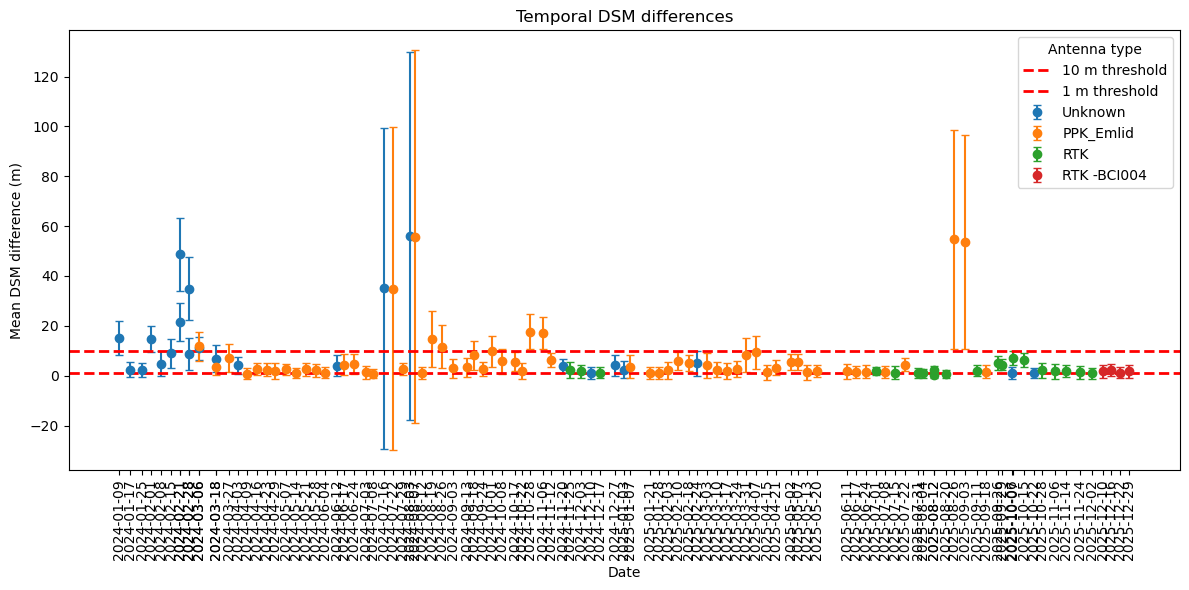

In [78]:
import matplotlib.pyplot as plt
import pandas as pd


# sort so the line follows time order
df = missions_list.sort_values('date')

df = missions_list[~missions_list['mean_diff'].isna()].sort_values('date')

# unique antenna types
antenna_types = df['antenna'].unique()

plt.figure(figsize=(12, 6))

for ant in antenna_types:
    sub = df[df['antenna'] == ant]

    plt.errorbar(
        sub['date'],
        sub['mean_diff'],
        yerr=sub['std_diff'],
        fmt='o',              # ONLY points, no line smoothing
        linestyle='none',     # ensures no connecting curve
        capsize=3,
        label=ant
    )

plt.axhline(10, color='red', linestyle='--', linewidth=2, label='10 m threshold')
plt.axhline(1, color='red', linestyle='--', linewidth=2, label='1 m threshold')
plt.xlabel("Date")
plt.ylabel("Mean DSM difference (m)")
plt.title("Temporal DSM differences")
plt.legend(title="Antenna type")
plt.xticks(
    df['date'],              # force all dates as ticks
    rotation=90
)
plt.tight_layout()

plt.show()

Looking at the outliers

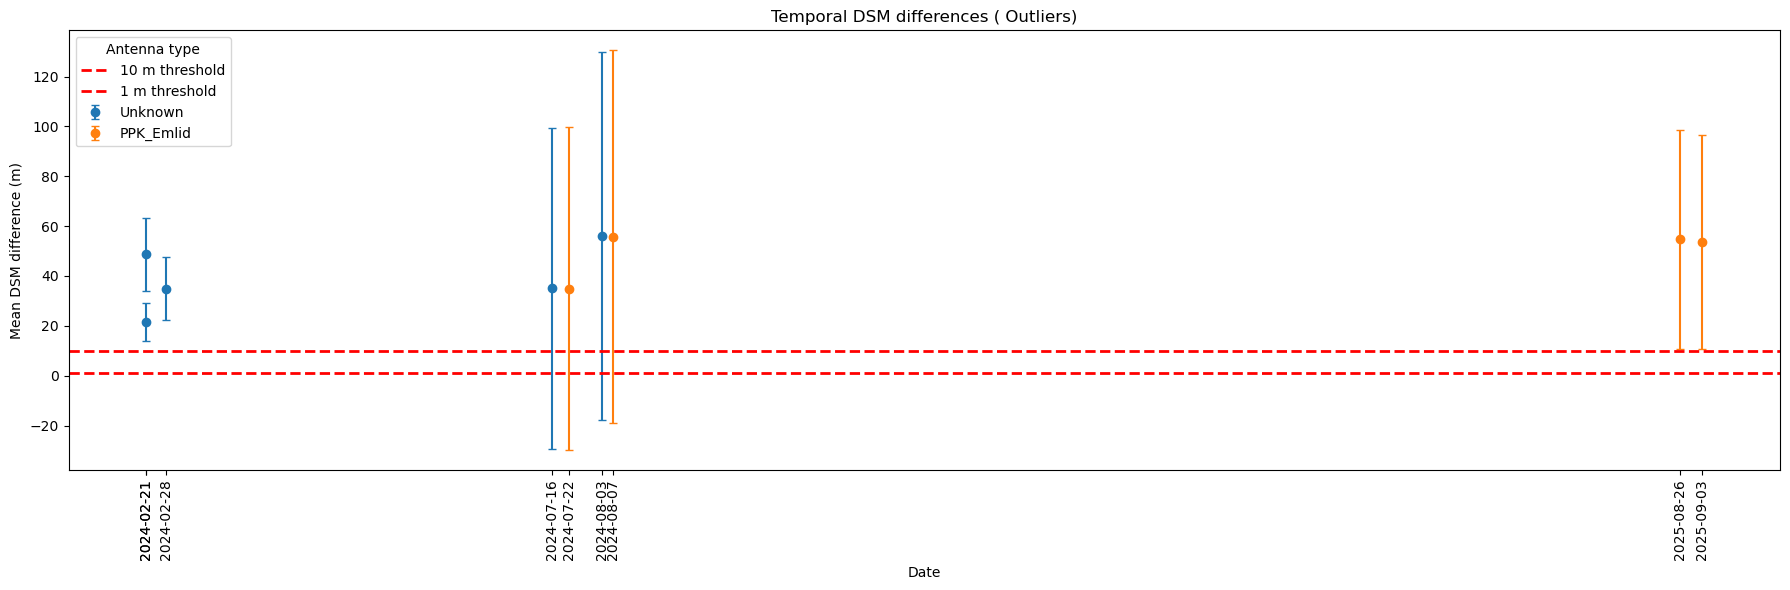

In [82]:
# sort so the line follows time order
df = missions_list[missions_list['mean_diff']> 20].sort_values('date')

# unique antenna types
antenna_types = df['antenna'].unique()

plt.figure(figsize=(18, 6))

for ant in antenna_types:
    sub = df[df['antenna'] == ant]

    plt.errorbar(
        sub['date'],
        sub['mean_diff'],
        yerr=sub['std_diff'],
        fmt='o',              # ONLY points, no line smoothing
        linestyle='none',     # ensures no connecting curve
        capsize=3,
        label=ant
    )

plt.axhline(10, color='red', linestyle='--', linewidth=2, label='10 m threshold')
plt.axhline(1, color='red', linestyle='--', linewidth=2, label='1 m threshold')
plt.xlabel("Date")
plt.ylabel("Mean DSM difference (m)")
plt.title("Temporal DSM differences ( Outliers)")
plt.legend(title="Antenna type")
plt.xticks(
    df['date'],              # force all dates as ticks
    rotation=90
)
plt.tight_layout()

plt.show()

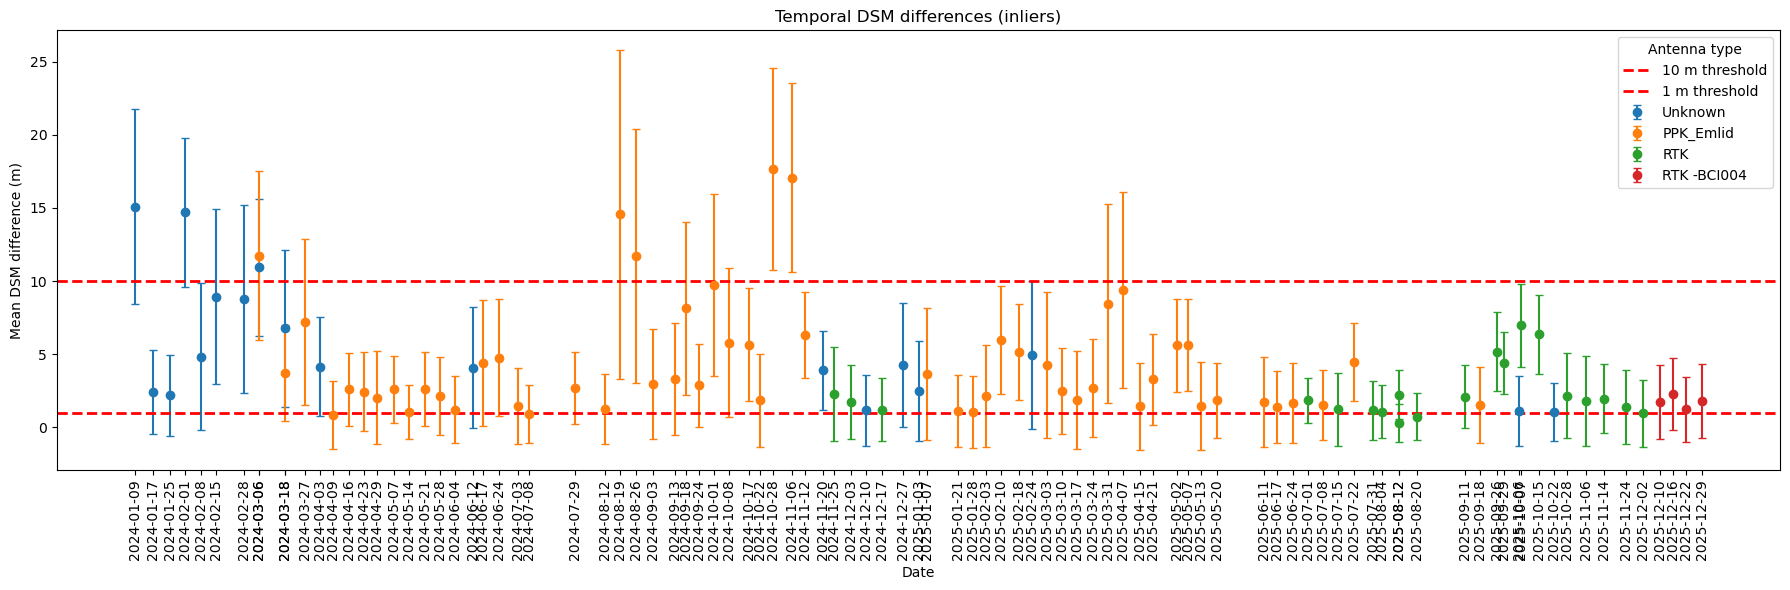

In [84]:
missions_list[missions_list['mean_diff'] > 20]


# sort so the line follows time order
df = missions_list[missions_list['mean_diff'] < 20].sort_values('date')

# unique antenna types
antenna_types = df['antenna'].unique()

plt.figure(figsize=(18, 6))

for ant in antenna_types:
    sub = df[df['antenna'] == ant]

    plt.errorbar(
        sub['date'],
        sub['mean_diff'],
        yerr=sub['std_diff'],
        fmt='o',              # ONLY points, no line smoothing
        linestyle='none',     # ensures no connecting curve
        capsize=3,
        label=ant
    )

plt.axhline(10, color='red', linestyle='--', linewidth=2, label='10 m threshold')
plt.axhline(1, color='red', linestyle='--', linewidth=2, label='1 m threshold')
plt.xlabel("Date")
plt.ylabel("Mean DSM difference (m)")
plt.title("Temporal DSM differences (inliers)")
plt.legend(title="Antenna type")
plt.xticks(
    df['date'],              # force all dates as ticks
    rotation=90
)
plt.tight_layout()

plt.show()

## Comparing changes after reprocessing / aligning missions

In [157]:
missions_reproces = """BCI_50ha_2024_03_06_M3E
BCI_50ha_2024_03_18_M3E
BCI_50ha_2024_03_27_M3E
BCI_50ha_2024_04_09_M3E
BCI_50ha_2024_04_16_M3E
BCI_50ha_2024_04_23_M3E
BCI_50ha_2024_04_29_M3E
BCI_50ha_2024_05_07_M3E
BCI_50ha_2024_05_14_M3E
BCI_50ha_2024_05_21_M3E
BCI_50ha_2024_05_28_M3E
BCI_50ha_2024_06_04_M3E
BCI_50ha_2024_06_17_M3E
BCI_50ha_2024_06_24_M3E
BCI_50ha_2024_07_03_M3E
BCI_50ha_2024_07_08_M3E
BCI_50ha_2024_07_22_M3E
BCI_50ha_2024_07_29_M3E
BCI_50ha_2024_08_07_M3E
BCI_50ha_2024_08_12_M3E
BCI_50ha_2024_08_19_M3E
BCI_50ha_2024_08_26_M3E
BCI_50ha_2024_09_03_M3E
BCI_50ha_2024_09_13_M3E
BCI_50ha_2024_09_18_M3E
BCI_50ha_2024_09_24_M3E
BCI_50ha_2024_10_01_M3E
BCI_50ha_2024_10_08_M3E
BCI_50ha_2024_10_17_M3E
BCI_50ha_2024_10_22_M3E
BCI_50ha_2024_11_06_M3E
BCI_50ha_2024_11_12_M3E
BCI_50ha_2024_11_25_M3E
BCI_50ha_2024_12_03_M3E
BCI_50ha_2024_12_17_M3E
BCI_50ha_2025_01_07_M3E
BCI_50ha_2025_01_14_M3E
BCI_50ha_2025_01_21_M3E
BCI_50ha_2025_01_28_M3E
BCI_50ha_2025_02_03_M3E
BCI_50ha_2025_02_10_M3E
BCI_50ha_2025_02_18_M3E
BCI_50ha_2025_03_03_M3E
BCI_50ha_2025_03_10_M3E
BCI_50ha_2025_03_17_M3E
BCI_50ha_2025_03_24_M3E
BCI_50ha_2025_03_31_M3E
BCI_50ha_2025_04_07_M3E
BCI_50ha_2025_04_15_M3E
BCI_50ha_2025_04_21_M3E
BCI_50ha_2025_05_02_M3E
BCI_50ha_2025_05_07_M3E
BCI_50ha_2025_05_13_M3E
BCI_50ha_2025_05_20_M3E
BCI_50ha_2025_06_11_M3E
BCI_50ha_2025_06_17_M3E
BCI_50ha_2025_06_24_M3E
BCI_50ha_2025_07_01_M3E
BCI_50ha_2025_07_08_M3E
BCI_50ha_2025_07_15_M3E
BCI_50ha_2025_07_22_M3E
BCI_50ha_2025_07_31_M3E
BCI_50ha_2025_08_04_M3E
BCI_50ha_2025_08_12_M3E
BCI_50ha_2025_08_20_M3E
BCI_50ha_2025_09_03_M3E
BCI_50ha_2025_09_11_M3E
BCI_50ha_2025_09_18_M3E
BCI_50ha_2025_09_26_M3E
BCI_50ha_2025_09_29_M3E
BCI_50ha_2025_10_07_M3E
BCI_50ha_2025_10_15_M3E
BCI_50ha_2025_10_28_M3E
BCI_50ha_2025_11_06_M3E
BCI_50ha_2025_11_14_M3E
BCI_50ha_2025_11_18_M3E
BCI_50ha_2025_11_24_M3E
BCI_50ha_2025_12_02_M3E
BCI_50ha_2025_12_10_M3E
BCI_50ha_2025_12_16_M3E
BCI_50ha_2025_12_22_M3E
BCI_50ha_2025_12_29_M3E"""

missions_repro = missions_reproces.split("\n")


missions_list_check = pd.read_csv("missions_list_dsm_diff_2026_07_12.csv")
missions_list_check["reprocessed"] = missions_list_check["mission"].isin(missions_repro)

In [96]:
missions_before = gpd.read_file("missions_list_dsm_diff_2026_05_22.csv", index=False)

In [102]:
merged_df = pd.merge(missions_before, missions_list_check, on="mission", suffixes=("", "_after"))

In [103]:
import pandas as pd

# List of columns you need as floats
float_cols = [
    "mean_diff_crownmap",
    "std_diff_crownmap",
    "mean_diff_crownmap_after",
    "std_diff_crownmap_after",
]

# 1. Force convert columns to float, turning unconvertible items into NaN
for col in float_cols:
    if col in merged_df.columns:
        merged_df[col] = pd.to_numeric(merged_df[col], errors="coerce")

# 2. Drop rows where the primary values couldn't be converted (optional but recommended)
merged_df = merged_df.dropna(subset=["mean_diff_crownmap", "mean_diff_crownmap_after"])

# 3. Verify the data types to be absolutely sure
print(merged_df[float_cols].dtypes)

mean_diff_crownmap          float64
std_diff_crownmap           float64
mean_diff_crownmap_after    float64
std_diff_crownmap_after     float64
dtype: object


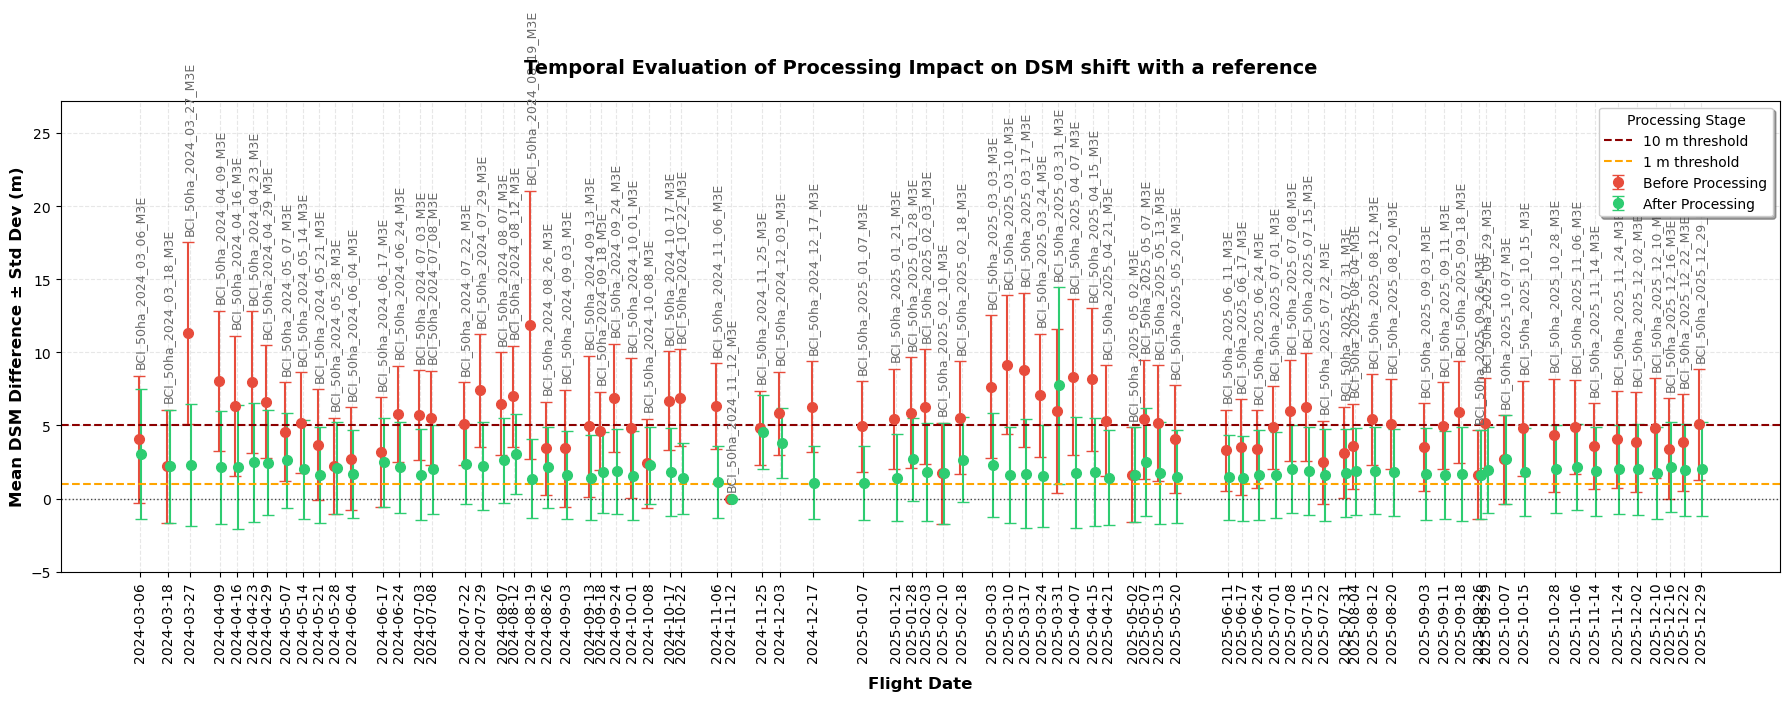

In [119]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Clean and sort your merged dataframe by date
merged_df["date"] = pd.to_datetime(merged_df["date"])
# (Assuming your merged dataframe is named merged_df and 'date' is in datetime format)
df_clean = merged_df[(merged_df["reprocessed"])].sort_values("date")
# & (merged_df["mean_diff_crownmap"] < 20)
# Ensure date is parsed to pandas datetime if it isn't already
df_clean["date"] = pd.to_datetime(df_clean["date"])

# 2. Initialize the plot layout
fig, ax = plt.subplots(figsize=(18, 7))

# Create a small horizontal offset (e.g., 12 hours) so Before and After sit side-by-side
time_offset = pd.Timedelta(hours=12)

# 3. Plot the "BEFORE" processing data
ax.errorbar(
    df_clean["date"] - time_offset,  # Shifted slightly left
    df_clean["mean_diff_crownmap"],
    yerr=df_clean["std_diff_crownmap"],
    fmt="o",
    color="#e74c3c",  # Red-ish
    ecolor="#e74c3c",
    elinewidth=1.5,
    capsize=4,
    markersize=7,
    linestyle="none",
    label="Before Processing",
)

# 4. Plot the "AFTER" processing data
ax.errorbar(
    df_clean["date"] + time_offset,  # Shifted slightly right
    df_clean["mean_diff_crownmap_after"],
    yerr=df_clean["std_diff_crownmap_after"],
    fmt="o",
    color="#2ecc71",  # Green-ish
    ecolor="#2ecc71",
    elinewidth=1.5,
    capsize=4,
    markersize=7,
    linestyle="none",
    label="After Processing",
)

# 5. Add text labels for the mission names right above/below the points
for idx, row in df_clean.iterrows():
    ax.text(
        row["date"],
        max(
            row["mean_diff_crownmap"] + row["std_diff_crownmap"],
            row["mean_diff_crownmap_after"] + row["std_diff_crownmap_after"],
        )
        + 0.5,
        row["mission"],
        rotation=90,
        ha="center",
        va="bottom",
        fontsize=9,
        color="dimgray",
    )

# Threshold lines
ax.axhline(5, color="darkred", linestyle="--", linewidth=1.5, label="10 m threshold")
ax.axhline(1, color="orange", linestyle="--", linewidth=1.5, label="1 m threshold")
ax.axhline(0, color="black", linestyle=":", linewidth=1, alpha=0.7)

# Formatting labels, ticks, and titles
ax.set_xlabel("Flight Date", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("Mean DSM Difference ± Std Dev (m)", fontsize=12, fontweight="bold")
ax.set_title(
    "Temporal Evaluation of Processing Impact on DSM shift with a reference",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

# Force all exact flight dates as ticks on the X-axis
ax.set_xticks(df_clean["date"])
ax.set_xticklabels(
    df_clean["date"].dt.strftime("%Y-%m-%d"), rotation=90, fontsize=10
)

ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(title="Processing Stage", loc="upper right", frameon=True, shadow=True)

# Give extra headroom at the top for vertical mission labels
ax.set_ylim(df_clean["mean_diff_crownmap"].min() - 5, ax.get_ylim()[1] + 5)

plt.tight_layout()
plt.show()